# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [12]:
import jax
from jax import random as jrd
from jax import numpy as jnp
from jax import debug as jdb
from jax import lax
import graph_tool as gt
from graph_tool.all import *
import copy
from typing import NamedTuple
from functools import partial


(ipykernel_launcher.py:8196): dbind-WARNING **: 12:38:50.513: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [ ]:
# parameters of the simulation
par = {'key': jrd.key(1634),       # original key for random generation (this sets reproducibility)
     'N': 10,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0.5,         # probability for each cell of having a self link
     'length_powerlaw': 1,         # exponent of the wire length power law (DA DEFINIRE!!!)
     'a_transfer': 1,                 # a parameter in the initial shape of the transfer function f=a*x+b
     'b_transfer': 0,                 # b parameter in the initial shape of the transfer function f=a*x+b
     'x_n': jnp.arange(-10,10,200),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'N_sol': 10}                       # number of solutions (individuals, networks) considered in the simulation

In [ ]:
# A QUANTO PARE IN REALTà QUESTA FUNZIONE NON MI SERVE, PERCHé VADO SEMPLICEMENTE A GENERARE TUTTE LE KEYS 
# CHE MI SERVONO NEL LOOP INIZIALE E POI LE DO IN INPUT AD OGNI FUNZIONE CHE NE NECESSITA
# define a quick function for generating a new random key from par['key'] and update par['key']
def gen_key(par:dict) -> tuple[jnp.ndarray,dict]:  # JAXXED!
    """Function to generate a new key, used for random generation in JAX, and update the current key
       present in par.

    Args:
        par (dict): dictionary of parameters, including also the current key.

    Returns:
        tuple[jax.KeyArray,dict]: [new key, updated par dictionary]
    """
    key, subkey = jrd.split(par['key'])     # generate a random key by splitting the key in par
    par['key'] = key                        # update the key in par
    return subkey, par                      # I have to return also par, otherwise, bc of JIT's rules, par['key'] won't update

# PROVO A DEFINIRE UNA NAMED TUPLE CONTENENTE TUTTI I PARAMETRI DEL NETWORK (?)
class NetworkParams(NamedTuple):
    """NamedTuple class for the parameters of the network."""
    J: jnp.ndarray          # weight matrix
    C: jnp.ndarray          # connectivity matrix
    B: jnp.ndarray          # bias matrix
    G: Graph                # Graph of the network (Graph_tool)
    state: jnp.ndarray      # values of the cells in the network
    transfer: jnp.ndarray   # array of the transfer functions of the single cells in the network
    N: int = 0              # side lenght of the squared lattice (number of cells = N**2)
    fitness: float = -1.     # fitness value of the network
    
# ORA DEFINISCO LA CLASSE NETWORK, CHE è DI FATTO SOLO UN NAMESPACE PER I VARI METODI
# CHE USO SUL SINGOLO NETWORK, I.E. 
# - GENERATE(PAR,NETPAR): CREA (IN REALTà NON CREA L'OGGETTO) UN NETWORK RANDOM DATI I PARAMETRI 
#   PAR E RITORNA I PARAMETRI DEL NETWORK (NETPAR) AGGIORNATI
# - COMPUTE_FITNESS(PAR,NETPAR): CALCOLA LA FITNESS DEL NETWORK ATTRAVERSO IL METODO FF() E
#   RITORNA TALE FITNESS.
# - FF(INPUT(S),NETPAR): FA IL 'FEED-FORWARD' DEL NETWORK DATO UN SET DI INPUT E RITORNA 
#   LO STATE (OSSIA L'ARRAY DEGLI STATI 0 O 1 DELLE SINGOLE CELL)

class Network():
    
    def generate(self,subkeys:jnp.ndarray,par:dict) -> NetworkParams:  # JAXXED!
    #def generate(self,subkeys:jnp.ndarray,N:int,p_self_link:float,N_Fourier:int) -> NetworkParams:  # JAXXED!
        """Generate a random network given the parameters par by updating the 
           NetPar object.

        Args:
            subkeys (jnp.ndarray): array of at least 4 keys for pseudorandom generation.
            par (dict): simulation/generation parameters.

        Returns:
            NetPar (NetworkParams): returns the new network's parameters set. 
        """
        N = par['N']                                      
        J = jrd.uniform(subkeys[0],shape=(N**2,N**2))                 # uniformly populate the weights in the weight matrix J                                        # generate the subkey for the random generation in the following line
        B = jrd.normal(subkeys[1],shape=(N**2,N**2))                  # extract from a normal distribution centered in 0 with st. dv. = 1 the biases (spero vada bene fatto così)
        idx = jnp.arange(N**2)
        row_idx = idx // N
        col_idx = idx % N
        row_diff = row_idx[:, None] - row_idx[None, :]
        col_diff = col_idx[:, None] - col_idx[None, :]
        dist_matrix = jnp.sqrt(row_diff**2 + col_diff**2)
        prob_matrix = jnp.where(jnp.eye(N**2, dtype=bool),  # Create the probability matrix for connectivity
            par['p_self_link'],1/dist_matrix)
        C = jnp.where(jrd.bernoulli(subkeys[2], jnp.array(prob_matrix)),1,0)    # Generate C  
        G = Graph(jnp.column_stack(jnp.nonzero(C)))         # Generate the Graph given the connectivity matrix
        state = jrd.normal(subkeys[3],shape=(N**2,))        # Randomly assign a state value to each cell distributed as a normal around 0
        transfer = jnp.ones((N**2,par['N_Fourier']))          # Initialize all the coefficients of the FT to one
        NetPar = NetworkParams(J,C,B,G,state,transfer,N)              # I don't specify the fitness argument so it stays as default (-1)
        fitness, state = self.compute_fitness(par,NetPar)                      # Compute the fitness value of the network (also updates the state)
        return NetworkParams(J,C,B,G,state,transfer,N,fitness)           # return the set of updated parameters
    
    def compute_fitness(self,par:dict,NetPar:NetworkParams,verb=None) -> tuple[float,jnp.ndarray]:    # JAXXED!
        fitness = 0.                # I need this check, bc otherwise I risk adding fitness over fitness  
        for i,input in enumerate(par['input_set']):
            output,state = self.ff(input,NetPar)
            if verb is not None:
                jdb.print('Input: {input} -> {output}',input=input,output=output)
            norm_factor = NetPar.G.num_vertices()**2-NetPar.G.num_vertices()            # normalize by N(N-1)
            target_dist = (par['target_set'][i] - output)**2                            # square distance between network output and target (theoretical) output
            volume_cost = (jnp.sum(NetPar.C.reshape(-1))/norm_factor)**2                # average wiring volume cost (i.e. # of links)
            dist = shortest_distance(NetPar.G, directed=True).get_2d_array()            # calculate the shortest path length for each pair of vertecies
            dist = jnp.where(dist >= 2147483647, 0, dist)                               # set each value that overflows (bc no path exists) to 0
            length_cost = (jnp.sum((NetPar.C.reshape(-1) * dist.reshape(-1))
                                    **par['length_powerlaw'])/norm_factor)**2            # average wiring length cost
            path_cost = (jnp.sum(dist,axis=[0,1])/norm_factor)**2                       # average shortest path length cost
            if verb is not None:
                jdb.print('Target distance:{d}',d=target_dist)
                jdb.print('Volume cost:{d}',d=volume_cost)
                jdb.print('Length cost:{d}',d=length_cost)
                jdb.print('Path cost:{d}',d=path_cost)
            fitness += jnp.exp(target_dist + volume_cost + length_cost + path_cost) # take the exponential of the sum of the costs (weighted if needed)
        fitness /= len(par['input_set'])    
        return fitness, state
    # then you call NetPar.fitness, NetPar.state = n.compute_fitness(...)
    
    def ff(self, input:list, NetPar:NetworkParams, verb:int=0):     # JAXXED!
        # set the value of the two inputs cells through the input value
        state = NetPar.state
        state = state.at[0].set(input[0])                        # cell in the upper left corner of the 2D lattice
        state = state.at[(NetPar.N - 1) * NetPar.N-1].set(input[1])    # cell in the lower left corner of the 2D lattice
        # Precompute the contributions for each cell to optimize the loop (this is incredibly faster)
        contributions = jnp.dot(NetPar.C * NetPar.J, state) + jnp.sum(NetPar.B, axis=1)      # weight x value + bias
        #for s in range(NetPar.N**2):
            # PROSSIMA RIGA DA METTERE A POSTO UNA VOLTA CHE è STATA DEFINITA la transfer function
            #NetPar.transfer[s](contributions[s])           # pass all the contributions through the transfer function to determine the value of the cell
        if verb > 0: 
            jdb.print('State of each cell: {s}',s=state)
        output = state[-1]                          # the cell in the right lower corner is the output
        return output, state

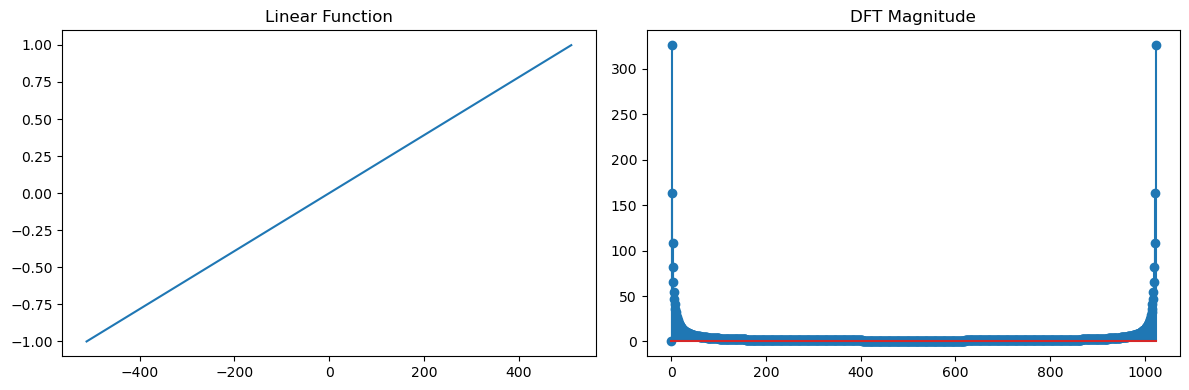

In [15]:
import numpy as np
import matplotlib.pyplot as plt

N = 1024            # fft works better with N = 2^k with some k (so N it's a power of 2)
n = jnp.arange(-N/2,N/2)
a = 1.0
b = 0.0
f = (a * n + b)/(N/2)

F = jnp.fft.fft(f)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(n, f)
plt.title("Linear Function")

plt.subplot(1, 2, 2)
plt.stem(jnp.abs(F))
plt.title("DFT Magnitude")
plt.tight_layout()
plt.show()


[ 0.          0.00097656  0.00195312 ... -0.00292969 -0.00195312
 -0.00097656]


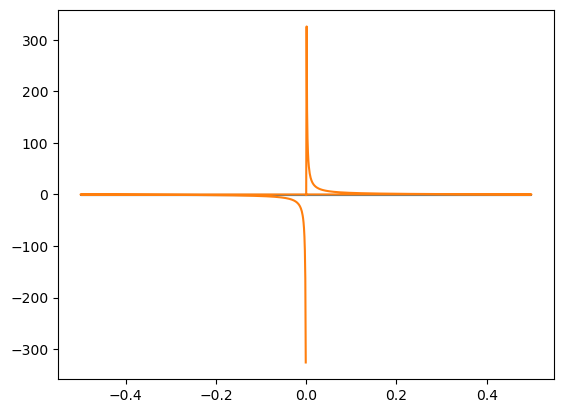

In [ ]:
freq = jnp.fft.fftfreq(f.shape[-1])
plt.plot(freq, F.real, freq, F.imag)
print(freq)

/home/pietromalagoli/miniconda3/envs/uni/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/pietromalagoli/miniconda3/envs/uni/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


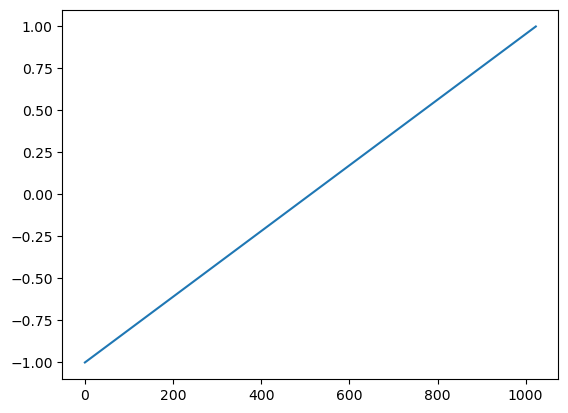

In [8]:
iF = np.fft.ifft(F)
plt.plot(iF)

In [57]:
# Generate random keys
subkeys = jrd.split(par['key'],5)
par['key'] = subkeys[-1]            # set the last key of subkeys as the new original key

In [60]:
par['N'] = 10
n = Network()
NetPar = n.generate(subkeys,par)

In [61]:
fitness, state = n.compute_fitness(par,NetPar)
print(fitness)

49.174137


Fitness: 49.174137115478516


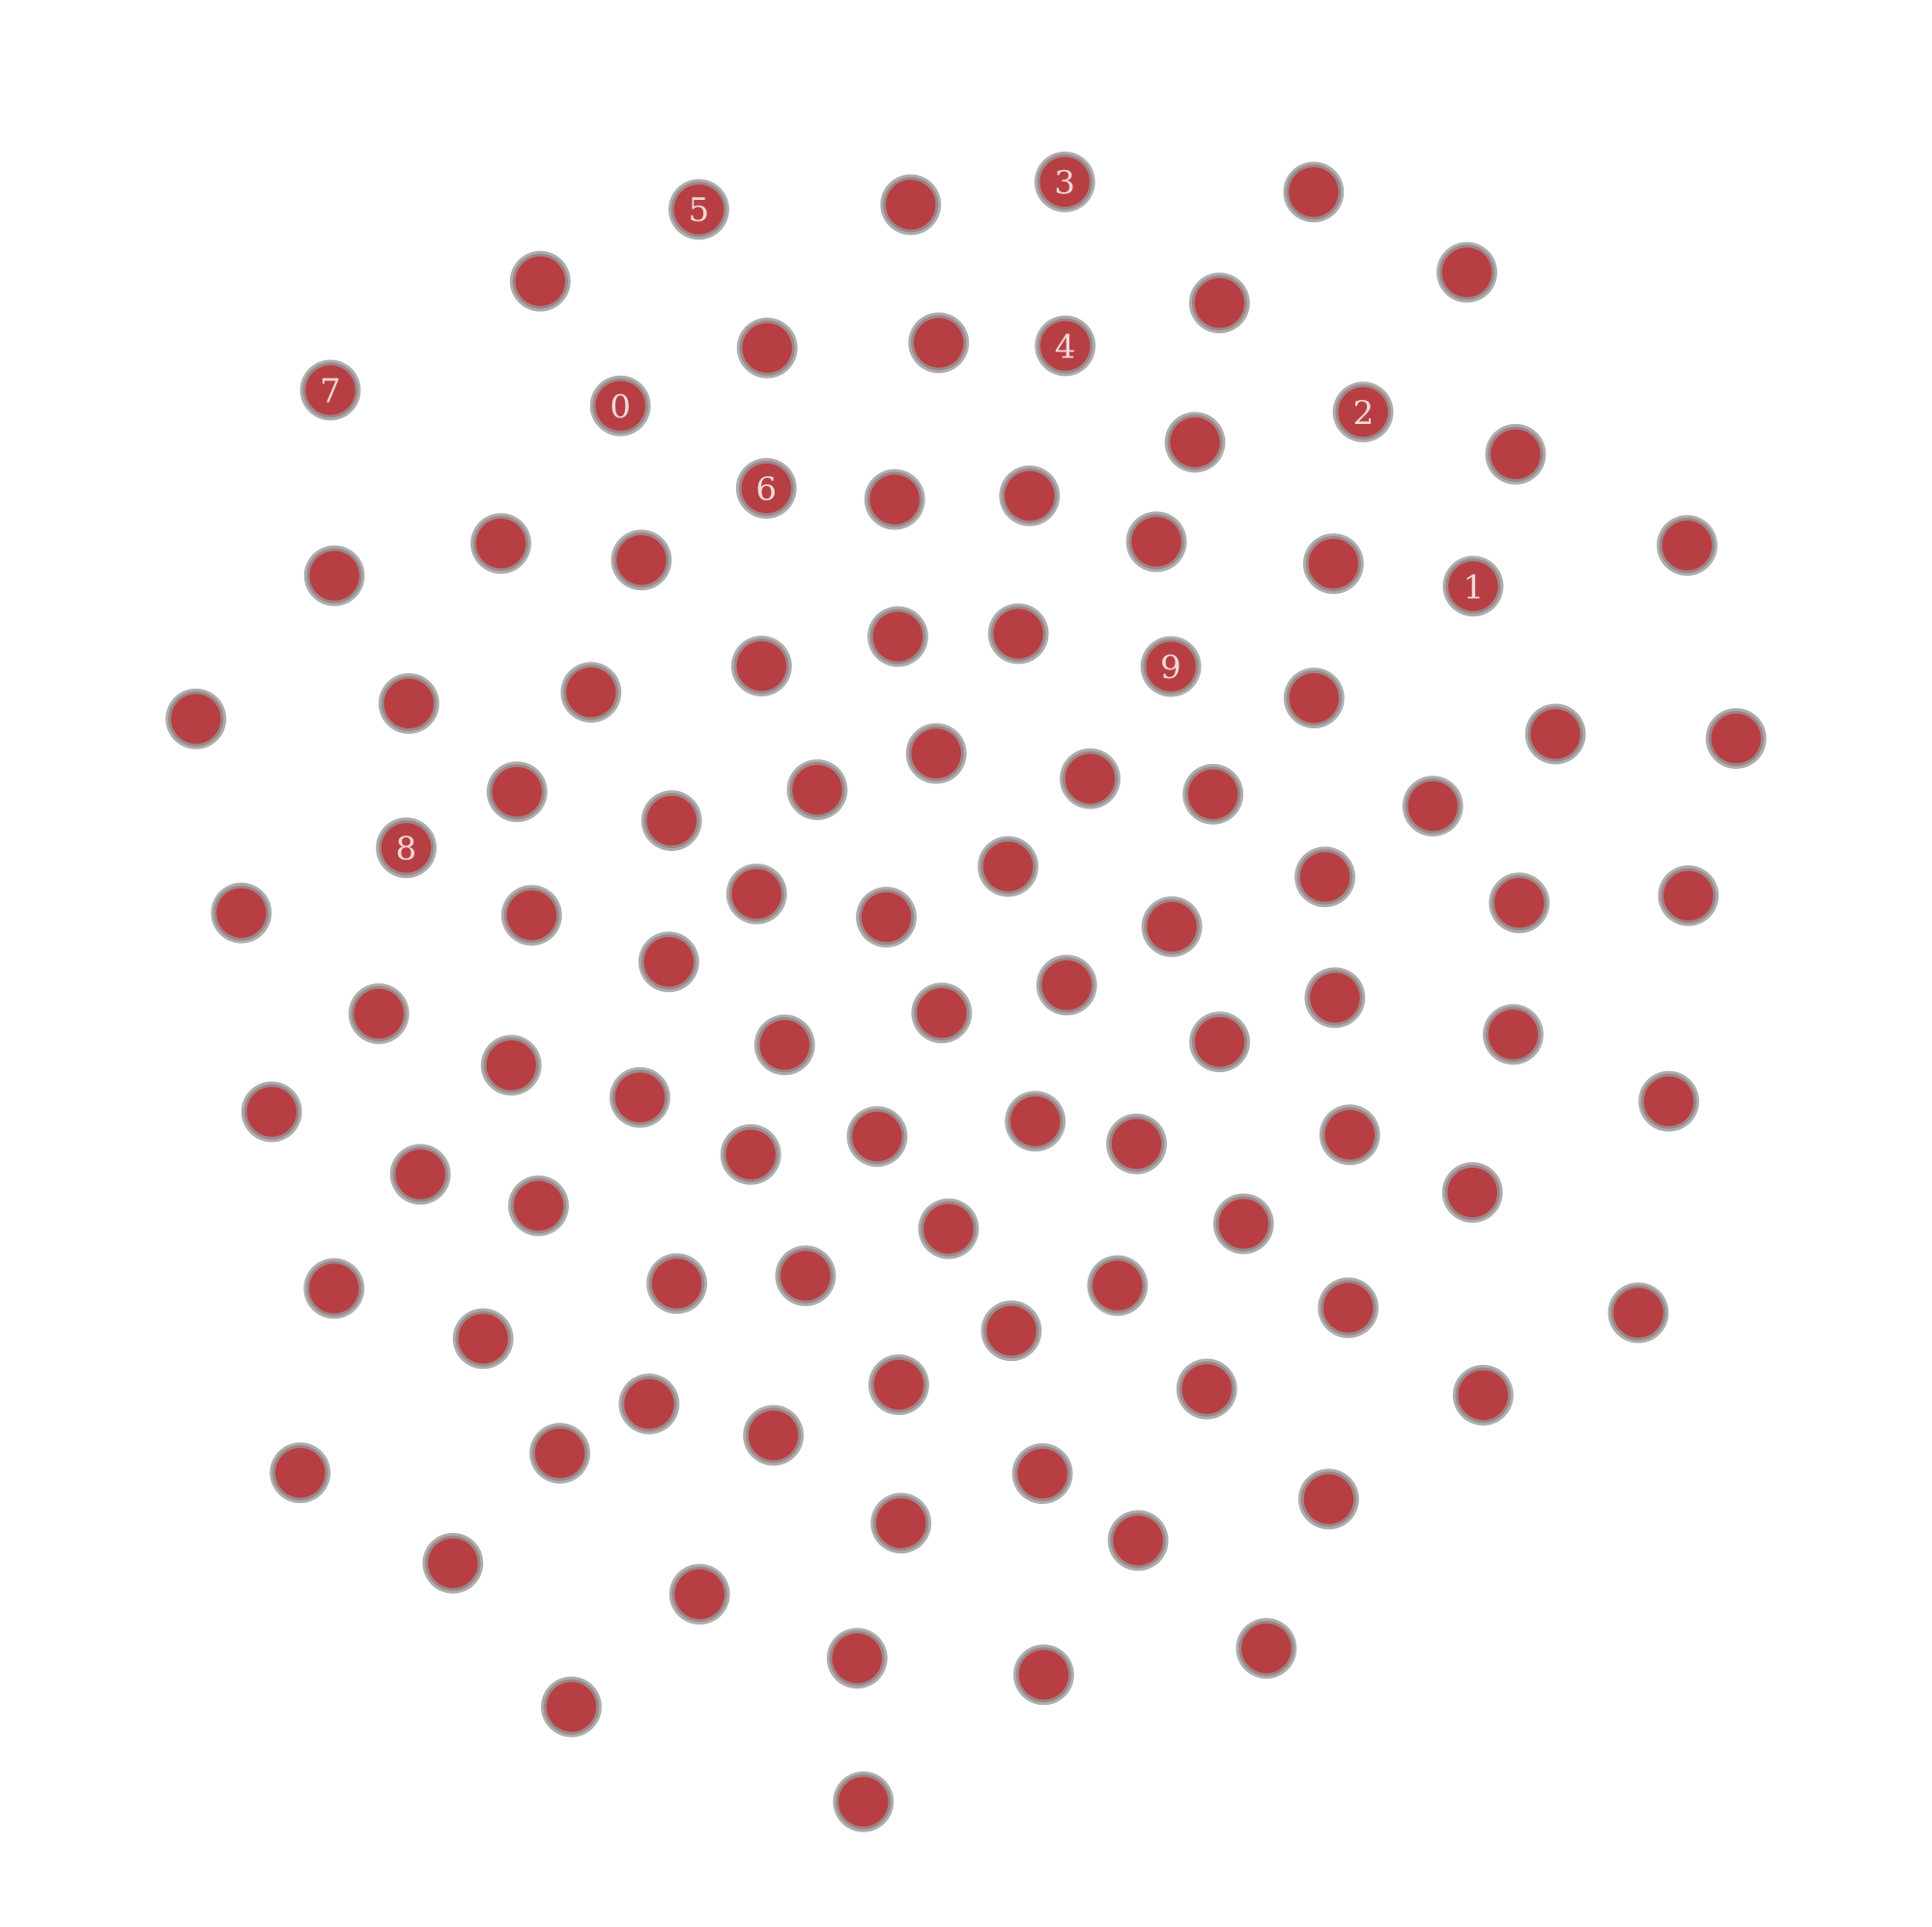

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fce28124110, at 0x7fce2810f350>

In [62]:
n = Network()
NetPar = n.generate(subkeys,par)
print(f'Fitness: {NetPar.fitness}')
graph_draw(NetPar.G,vertex_text=NetPar.G.new_vertex_property('string',jnp.arange(NetPar.N)),edge_color='w',output_size=(1000,1000))

In [ ]:
sols = []
for _ in range(20):
    n = Network()
    n.generate(par)
    sols.append(n)

Now I define the genetic algorithm for the evolution:

In [ ]:
############# GENETIC ALGORITHM #################
def crossover(subkey:jnp.ndarray,par1:NetworkParams,par2:NetworkParams):      # PER ORA IMPLEMENTO SOLO PER CChromo
    # Implements the crossover ricombination given 2 parent NetworkParams
    # and returns 2 offspring NetworksParams.
    if par1.C.shape != par2.C.shape:
        jdb.print('Error: length mismatch between the chromosomes of the two parents!')
        raise ValueError
    offspring
    cut_idx = jrd.choice(subkey,jnp.arange(len(par1.Cchromo)))  # randomly pick where to cut the chromosomes
    

def evolution(par:dict, verb:int=1,early_stop:bool=True):
    if par(['N_sol']) % 2 != 0:     # N_sol must be even
        jdb.print('Error:The number of solutions N_sol must be an even positive number.')
        raise ValueError
    # Generate the initial batch of solutions
    solutions = []
    for _ in range(par['N_sol']):
        # Generate a solution
        n = Network()
        n.generate(par)     # already computes also the fitness value
        solutions.append(n)
    solutions = jnp.array(solutions)
    # Initiate some container for statistic
    Fmean_values = []
    
    ##  EVOLUTION
    for iter in range(par['n_iter']):
        # Compute the mean fitness for statistics
        mean_fit = jnp.sum(jnp.array([sol.fitness for sol in solutions])) / par['N_sol']    # Here I don't have to divide also by 4, because I've already done it in the compute_fitness method
        # Save the old solution set for possible early stopping
        solutions_old = []
        for sol in solutions:
            solutions_old.append(copy.deepcopy(sol))
        # SELECTION
        solutions = jnp.sort(solutions,key=lambda sol: sol.fitness)    # sort in ascending order based on fitness
        subkey, par = gen_key(par)
        parents_idx = jrd.choice(subkey,jnp.arange(par['N_sol']),                       # must be with replacement, since the same individual 
                                 shape=(par['N_sol']/2,2),replace=True,                 # can be chosen to be parent multiple times
                                 p=jnp.array([1/sol.fitness for sol in sols])           # p: probability of being chosen as a parent, inversly proportional to the fitness
                                 /jnp.sum(jnp.array([sol.fitness for sol in sols]))) 
        
        
        